In [1]:
pip install EMD-signal

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import PyEMD
print(PyEMD.__version__)

1.6.4


In [ ]:
import matplotlib.pyplot as plt
# 导入matplotlib的pyplot模块，用于数据可视化。
import tensorflow as tf
# 导入tensorflow库，用于深度学习模型的构建和训练
from PyEMD import EMD, EEMD, CEEMDAN
# 从pyemd库导入EMD, EEMD, CEEMDAN，用于模态分解
import pandas as pd
# 导入pandas库，用于数据处理和分析
import warnings
# 导入warnings库，用于控制警告消息
warnings.filterwarnings("ignore")

In [4]:
gpus = tf.config.experimental.list_physical_devices(device_type='GPU')
for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu, True)

In [5]:
# 用来正常显示中文/英文标签（保持与模板一致）
plt.rcParams['font.sans-serif'] = ['Times New Roman']
# 用来正常显示负号
plt.rcParams['axes.unicode_minus'] = False

In [6]:
df_raw_data = pd.read_csv('Philippines-DroughtPrediction.csv')

# 确保时间列为Datetime并按时间排序
df_raw_data['Month'] = pd.to_datetime(df_raw_data['Month'])
df_raw_data = df_raw_data.sort_values('Month').reset_index(drop=True)

# 只分解目标 cdd（推荐做法），构造与模板一致的 Series 写法
series_close = pd.Series(
    df_raw_data['cdd'].astype(float).values,
    index=df_raw_data['Month']
)
# 创建一个pandas的Series对象。
# df_raw_data['cdd'].values提取'cdd'列的值作为Series的数据。
# index=df_raw_data['Month']设置Series的索引为时间戳（YYYY-MM）
print(series_close)

Month
1950-01-01    3.07
1950-02-01    4.80
1950-03-01    4.28
1950-04-01    4.77
1950-05-01    3.70
              ... 
2023-08-01    4.13
2023-09-01    1.75
2023-10-01    1.96
2023-11-01    2.89
2023-12-01    3.95
Length: 888, dtype: float64


In [7]:
def ceemdan_decompose(series=None, trials=100):
    # 定义CEEMDAN分解函数。
    # series: 待分解的时间序列数据。
    # trials: CEEMDAN的试验次数，用于生成噪声。

    decom = CEEMDAN()
    # 创建CEEMDAN对象。

    decom.trials = trials
    # 设置CEEMDAN对象的试验次数。

    df_ceemdan = pd.DataFrame(decom(series.values).T)
    # 对时间序列数据执行CEEMDAN分解，并将结果转置后转换为DataFrame。

    df_ceemdan.columns = ['imf' + str(i+1) for i in range(len(df_ceemdan.columns))]
    # 为DataFrame的每一列命名，表示每个内在模态函数（IMF）。

    return df_ceemdan
    # 返回分解结果的DataFrame。

In [8]:
df_ceemdan = ceemdan_decompose(series_close)
# 对series_close进行CEEMDAN分解，并返回结果的DataFrame。

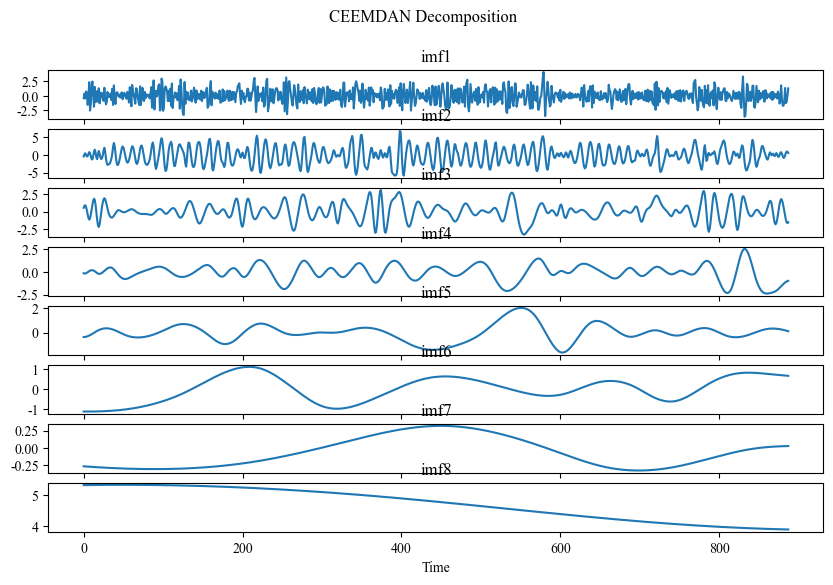

In [9]:
# 可视化VMD分解结果
fig, axs = plt.subplots(nrows=len(df_ceemdan.columns), figsize=(10, 6), sharex=True)
# 创建一个绘图对象和多个子图对象。
for i, col in enumerate(df_ceemdan.columns):
    axs[i].plot(df_ceemdan[col])
    axs[i].set_title(col)
    # 遍历每个模态并绘制在子图上。

plt.suptitle('CEEMDAN Decomposition')
# 设置图表的总标题。

plt.xlabel('Time')
# 设置x轴的标签。

plt.show()
# 显示图表。

In [12]:
print(df_ceemdan)
df_ceemdan.to_excel("CEEMDAN-PHILIPPINES-CDD.xlsx",index=False)
#保存数据为CEEMDAN-CHINA-CDD.xlsx

         imf1      imf2      imf3      imf4      imf5      imf6      imf7  \
0   -0.421549 -0.472646  0.527733 -0.154662 -0.360387 -1.110539 -0.266056   
1    0.383786  0.167155  0.837064 -0.181291 -0.357389 -1.110963 -0.266892   
2   -0.469886  0.431549  0.899513 -0.182115 -0.348971 -1.111313 -0.267721   
3    0.730150 -0.062718  0.643377 -0.154578 -0.335453 -1.111587 -0.268541   
4    0.495891 -0.475537  0.153712 -0.105400 -0.317276 -1.111786 -0.269355   
..        ...       ...       ...       ...       ...       ...       ...   
883  1.343841 -0.210773 -0.604391 -1.176066  0.184577  0.667724  0.025212   
884 -1.277488  0.549856 -1.167642 -1.111260  0.167695  0.664116  0.025478   
885 -1.098676  0.925645 -1.544216 -1.057712  0.150122  0.660493  0.025717   
886  0.006491  0.847262 -1.658968 -1.017483  0.131897  0.656853  0.025930   
887  1.272043  0.513623 -1.533377 -0.992079  0.113063  0.653194  0.026119   

         imf8  
0    5.328107  
1    5.328530  
2    5.328945  
3    5.3293